# Question 2 — AOI and BUC

AOI describes high-income groups. BUC counts combinations of attributes.

Run from `assignments/A2`. Full report: [report.md](docs/report.md). Code: [aoi.py](aoi.py), [buc.py](buc.py) and [checks.py](checks.py).

## 1. What does the data contain?

Check record counts and income classes. Each record counts once; `instance_weight` is excluded.

In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory
from time import perf_counter
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from aoi import load_data, load_hierarchies, generalize, check_hierarchies
from buc import ALL, DTYPE, encode_frame, encode_csv, buc_memory, buc_disk
from checks import run_checks, duckdb_cube

source = Path("M26 DA A2/M26_DA_A2_Part2.csv")
data = load_data(source)
print("Rows and columns:", data.shape)
data["income"].value_counts().to_frame("records")

Rows and columns: (299285, 42)


,records
income,
<=50K,280717
>50K,18568


The data contains **299,285 records, 42 columns** and **18,568 high-income records (6.20%)**.

### Check missing values

Treat `?`, `NA` and blanks as `Unknown`, keeping `Not in universe` separate. Check missing values by year.

In [2]:
print("Repeated rows beyond the first:", data.duplicated().sum())
pd.crosstab(data["year"], data["migration_reg"].eq("Unknown"),
            colnames=["Migration is unknown"])

Repeated rows beyond the first: 6735


Migration is unknown,False,True
year,,
94,149643,0
95,0,149642


Removing unknown migration values would remove all 1995 records, so they stay. The **6,735 repeated rows** also stay: identical responses do not prove duplicate entries.

## 2. AOI: which broader groups describe high income?

Use five hierarchies from `hierarchies.json`: age, education, industry, occupation and worker class. First, check the four supplied detailed/summary pairs.

In [3]:
hierarchies = load_hierarchies("hierarchies.json")
hierarchy_checks = check_hierarchies(data, hierarchies)
hierarchy_checks[["source", "summary", "ambiguous_rows", "mismatches"]]

,source,summary,ambiguous_rows,mismatches
0,industry_code_detailed,industry_code_major,0,0
1,occupation_code_detailed,occupation_code_major,0,0
2,household_family_status,household_summary,279,0
3,state_prev_residence,region_prev_residence,1974,0


Industry and occupation map exactly. **279 household** and **1,974 previous-state** records have ambiguous mappings; these exceptions remain explicit.

### How much detail is useful?

Apply hierarchy levels until each attribute has at most **8 values**.

In [4]:
attributes = ["age", "education", "industry_code_detailed",
              "occupation_code_detailed", "class_of_worker"]
grouped = data[attributes].copy()
for column in attributes:
    hierarchy = hierarchies["attributes"][column]
    for level in range(len(hierarchy["levels"]) + 1):
        values = generalize(data[column], hierarchy, level)
        if values.nunique() <= 8:
            break
    grouped[column] = values

print("Values per attribute:")
display(grouped.nunique())
print("Distinct descriptions:", len(grouped.drop_duplicates()))

Values per attribute:


age                         5
education                   6
industry_code_detailed      8
occupation_code_detailed    7
class_of_worker             6
dtype: int64

Distinct descriptions: 1725


The **1,725 descriptions** exceed the chosen limit of **500**. Replace industry with `ALL` (any industry), keeping the other four attributes.

In [5]:
industry = hierarchies["attributes"]["industry_code_detailed"]
grouped["industry_code_detailed"] = generalize(
    data["industry_code_detailed"], industry, len(industry["levels"]))

print("Descriptions after removing industry:", len(grouped.drop_duplicates()))
assert len(grouped.drop_duplicates()) <= 500

Descriptions after removing industry: 439


This leaves **439 descriptions**, with every record retained.

### How are groups compared?

Calculate two percentages: **t-weight** (group high-income count / all high-income records) and **d-weight** (group high-income count / all records in that group).

In [6]:
grouped["income"] = data["income"]
counts = grouped.groupby(attributes + ["income"]).size().unstack(fill_value=0)
rules = counts.rename(columns={">50K": "high_income", "<=50K": "low_income"}).reset_index()

high_income_total = data["income"].eq(">50K").sum()
rules["total"] = rules["high_income"] + rules["low_income"]
rules["t_weight"] = 100 * rules["high_income"] / high_income_total
rules["d_weight"] = 100 * rules["high_income"] / rules["total"]

assert rules["total"].sum() == len(data)
assert rules["high_income"].sum() == high_income_total
assert np.isclose(rules["t_weight"].sum(), 100)

### Which groups cover most high-income records?

Rank characteristic rules by t-weight.

In [7]:
columns = ["age", "education", "occupation_code_detailed", "class_of_worker",
           "high_income", "low_income", "t_weight", "d_weight"]
characteristic = rules.sort_values("t_weight", ascending=False)
characteristic[columns].head(3).round(2)

income,age,education,occupation_code_detailed,class_of_worker,high_income,low_income,t_weight,d_weight
164,35-49,Bachelor,Professional and managerial,Private,1552,2453,8.36,38.75
225,35-49,Postgraduate,Professional and managerial,Private,1400,1019,7.54,57.88
224,35-49,Postgraduate,Professional and managerial,Government,673,1367,3.62,32.99


The largest group—35–49, bachelor, professional/managerial, private worker—contains **1,552 high-income records**: **t = 8.36%, d = 38.75%**.

### Which groups have a higher high-income share?

Rank discriminant rules by d-weight, requiring at least **100 high-income records** and **d > 6.20%**.

In [8]:
overall_share = 100 * high_income_total / len(data)
discriminant = rules[(rules["high_income"] >= 100) &
                     (rules["d_weight"] > overall_share)]
discriminant = discriminant.sort_values("d_weight", ascending=False)
discriminant[columns].head(3).round(2)

income,age,education,occupation_code_detailed,class_of_worker,high_income,low_income,t_weight,d_weight
226,35-49,Postgraduate,Professional and managerial,Self-employed,531,352,2.86,60.14
327,50-64,Postgraduate,Professional and managerial,Self-employed,296,200,1.59,59.68
326,50-64,Postgraduate,Professional and managerial,Private,571,409,3.08,58.27


The leading group—35–49, postgraduate, professional/managerial, self-employed—has **531/883 high-income records**: **d = 60.14%, t = 2.86%**. Its high-income share is high, but it covers a small part of the high-income class.

## 3. BUC: how many records match each combination?

Use **12 original dimensions**, excluding income and `instance_weight`, with the major industry/occupation categories.

In [9]:
dimensions = [
    "year", "sex", "race", "education", "marital_status", "employment_status",
    "class_of_worker", "industry_code_major", "occupation_code_major",
    "tax_filer_status", "household_summary", "region_prev_residence",
]
assert len(dimensions) >= 12
assert "instance_weight" not in dimensions

data[dimensions].nunique().to_frame("distinct values")

,distinct values
year,2
sex,2
race,5
education,17
marital_status,7
employment_status,8
class_of_worker,9
industry_code_major,24
occupation_code_major,15
tax_filer_status,6


### How does BUC count combinations?

Split groups recursively and stop below **30,000 records**: further conditions cannot increase counts. The implementation uses NumPy, without dataframe grouping or SQL. Categories become integer codes; `-1` represents `ALL`.

In [10]:
encoded, labels = encode_frame(data, dimensions)
cards = [len(labels[column]) for column in dimensions]
minsup = 30_000

cube, _ = buc_memory(encoded, dimensions, cards, minsup, measure="count")
print("Counts retained:", len(cube))
assert cube[(ALL,) * len(dimensions)] == len(data)

Counts retained: 3921


### Do the counts make sense?

Decode the labels and check that the unrestricted total equals **299,285**.

In [11]:
def readable_cube(cube, dimensions, labels):
    table = pd.DataFrame(cube.keys(), columns=dimensions)
    for column in dimensions:
        names = dict(enumerate(labels[column]))
        names[ALL] = "ALL"
        table[column] = table[column].map(names)
    table["support"] = list(cube.values())
    return table

cube_table = readable_cube(cube, dimensions, labels)
cube_table.sort_values("support", ascending=False).head(5)

,year,sex,race,education,marital_status,employment_status,class_of_worker,industry_code_major,occupation_code_major,tax_filer_status,household_summary,region_prev_residence,support
0,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,299285
3920,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,Not in universe,275818
2668,ALL,ALL,White,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,250978
3282,ALL,ALL,White,ALL,ALL,ALL,ALL,ALL,ALL,ALL,ALL,Not in universe,232036
3728,ALL,ALL,ALL,ALL,ALL,Children or Armed Forces,ALL,ALL,ALL,ALL,ALL,ALL,185459


The cube returns **3,921 counts**. Groups overlap, so summing these counts would count records multiple times.

### What if a group does not fit in memory?

With a **16 MiB** allowance, oversized groups go to temporary files; fitting groups run in memory. The allowance estimates algorithm working memory, not total Python memory.

In [12]:
temporary = TemporaryDirectory(prefix="question2-")
work = Path(temporary.name)
input_file = work / "records.bin"
output_file = work / "disk_cube.csv"

encode_csv(source, input_file, dimensions, labels)
assert np.array_equal(np.fromfile(input_file, dtype=DTYPE).reshape(encoded.shape), encoded)

with output_file.open("w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(dimensions + ["support"])

    def write_count(key, count):
        writer.writerow([*key, count])

    disk_stats = buc_disk(input_file, dimensions, cards, minsup, 16, emit=write_count)

print("Counts retained:", disk_stats.cells)
print("Groups written to disk:", disk_stats.spills)
assert disk_stats.spills > 0
assert disk_stats.peak_accounted_bytes <= disk_stats.budget_bytes

Counts retained: 3921
Groups written to disk: 370


The disk version also returns **3,921 counts**, with **370 groups written to disk**.

### Are both versions correct?

Compare every result against DuckDB CUBE, using **16 SQL batches covering all 4,096 attribute subsets** to avoid one oversized query.

In [13]:
disk_table = pd.read_csv(output_file)
assert not disk_table.duplicated(dimensions).any()
disk_cube = disk_table.set_index(dimensions)["support"].to_dict()
assert cube == disk_cube

sql_cube = duckdb_cube(encoded, dimensions, minsup)
assert cube == sql_cube
print("Every count matches: in-memory BUC, disk BUC and DuckDB.")

run_checks()

Every count matches: in-memory BUC, disk BUC and DuckDB.


,case,counts,disk_spills,passed
0,"random, support=1",357,14,True
1,"random, support=20",106,14,True
2,"random, support=100",12,11,True
3,"random, support=501",0,0,True
4,empty,0,0,True
5,one record,4,0,True
6,identical records,16,15,True
7,Unknown is different from ALL,8,0,True


The full-data comparison and small edge-case tests pass.

### What about income?

Check a separate four-dimensional income cube at support **100** against a direct DuckDB CUBE query.

In [14]:
income_dimensions = ["education", "sex", "class_of_worker", "income"]
income_data, income_labels = encode_frame(data, income_dimensions)
income_cards = [len(income_labels[column]) for column in income_dimensions]
income_cube, _ = buc_memory(income_data, income_dimensions, income_cards, 100)
assert income_cube == duckdb_cube(income_data, income_dimensions, 100)

income_table = readable_cube(income_cube, income_dimensions, income_labels)
income_table.query("income == '>50K' and sex == 'Male' and class_of_worker == 'ALL'").sort_values(
    "support", ascending=False).head(5)

,education,sex,class_of_worker,income,support
677,ALL,Male,ALL,>50K,14600
312,Bachelors degree(BA AB BS),Male,ALL,>50K,4573
421,High school graduate,Male,ALL,>50K,2370
499,Masters degree(MA MS MEng MEd MSW MBA),Male,ALL,>50K,2235
601,Some college but no degree,Male,ALL,>50K,2102


One result counts **4,573 male, bachelor-qualified, high-income records** across worker classes. This count alone does not give their high-income share.

## 4. What affects runtime?

Change one setting at a time, repeat **three times**, and report medians and ranges. Timing includes computation and disk work, excluding preparation and SQL checks.

The full run saves **39 measurements** in `results/benchmark_runs.csv` and updates four plots. Set `rerun_timings = False` to use saved measurements. No other result files are needed.

In [15]:
rerun_timings = False
if not rerun_timings:
    saved_runs = pd.read_csv("results/benchmark_runs.csv")
repeats = 3

def discard_count(key, count):
    pass

# A small untimed run warms up the BUC code before any new measurements.
if rerun_timings:
    buc_memory(encoded[:1000], dimensions, cards, 100, emit=discard_count)

### How can runs be timed consistently?

Prepare input before timing and discard output during timed runs.

In [16]:
def measure_disk(minsup=30_000, memory_mb=16, n_dimensions=12):
    selected = dimensions[:n_dimensions]
    rows = np.ascontiguousarray(encoded[:, :n_dimensions])
    path = work / "benchmark.bin"
    rows.tofile(path)
    measurements = []

    for repeat in range(repeats):
        start = perf_counter()
        stats = buc_disk(path, selected, cards[:n_dimensions], minsup,
                         memory_mb, emit=discard_count)
        elapsed = perf_counter() - start
        assert stats.peak_accounted_bytes <= stats.budget_bytes
        measurements.append({
            "repeat": repeat + 1, "minsup": minsup, "memory_mb": memory_mb,
            "dimensions": n_dimensions, "seconds": elapsed,
            "cells": stats.cells, "spills": stats.spills,
        })
    path.unlink()
    return measurements

### How are runs compared?

Summarize median time, range and output count with the same plotting function.

In [17]:
def plot_times(runs, parameter, label, filename):
    summary = runs.groupby(parameter).agg(
        median_s=("seconds", "median"), shortest_s=("seconds", "min"),
        longest_s=("seconds", "max"), counts=("cells", "first"), spills=("spills", "first"))
    error = [summary.median_s - summary.shortest_s,
             summary.longest_s - summary.median_s]
    plt.figure(figsize=(6, 3))
    plt.errorbar(summary.index, summary.median_s, yerr=error, marker="o", capsize=4)
    plt.xlabel(label)
    plt.ylabel("Time (seconds)")
    plt.xticks(summary.index)
    plt.tight_layout()
    plt.savefig(Path("results") / filename, dpi=150)
    plt.show()
    return summary.round(3)

### Does higher support save time?

Keep **12 dimensions and 16 MiB** fixed.

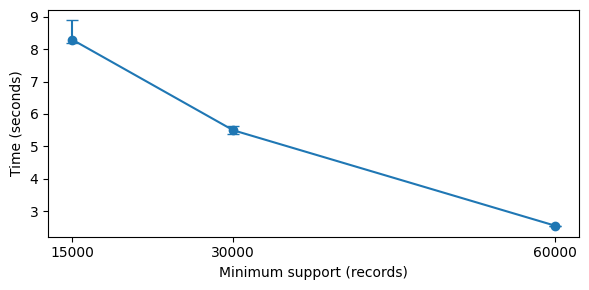

,median_s,shortest_s,longest_s,counts,spills
minsup,,,,,
15000,8.291,8.174,8.888,9593,483
30000,5.498,5.378,5.614,3921,370
60000,2.555,2.533,2.558,777,227


In [18]:
if rerun_timings:
    measurements = []
    for support in [15_000, 30_000, 60_000]:
        measurements.extend(measure_disk(minsup=support))
    support_runs = pd.DataFrame(measurements)
else:
    support_runs = saved_runs[saved_runs["experiment"] == "minsup"]

plot_times(support_runs, "minsup", "Minimum support (records)", "runtime_vs_minsup.png")

Raising support **15,000 → 60,000** changes time **8.291 → 2.555 s** and counts **9,593 → 777**. Higher support saves work but removes less frequent combinations.

### Does more memory help?

Keep **12 dimensions and support 30,000** fixed.

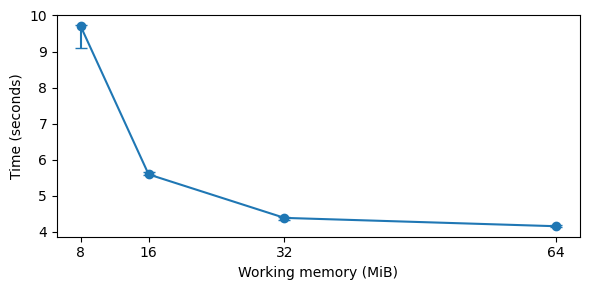

,median_s,shortest_s,longest_s,counts,spills
memory_mb,,,,,
8.0,9.701,9.103,9.742,3921,1920
16.0,5.592,5.577,5.666,3921,370
32.0,4.386,4.326,4.412,3921,44
64.0,4.154,4.143,4.179,3921,0


In [19]:
if rerun_timings:
    measurements = []
    for memory in [8, 16, 32, 64]:
        measurements.extend(measure_disk(memory_mb=memory))
    memory_runs = pd.DataFrame(measurements)
else:
    memory_runs = saved_runs[saved_runs["experiment"] == "memory"]

assert memory_runs["cells"].nunique() == 1
plot_times(memory_runs, "memory_mb", "Working memory (MiB)", "runtime_vs_memory.png")

Increasing memory **8 → 64 MiB** reduces disk-written groups **1,920 → 0** and changes time **9.701 → 4.154 s**. All runs retain **3,921 counts**.

### What happens with more dimensions?

Use the first **4, 8, 10 and 12 dimensions**, keeping **support 30,000 and 16 MiB** fixed.

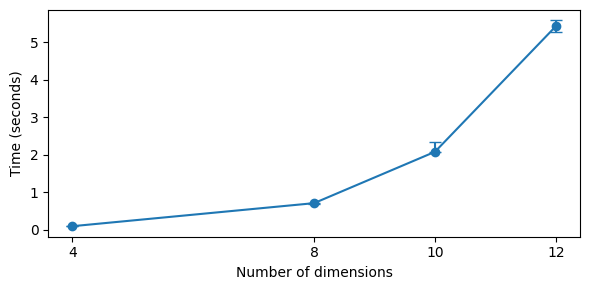

,median_s,shortest_s,longest_s,counts,spills
dimensions,,,,,
4,0.089,0.083,0.107,36,12
8,0.704,0.692,0.704,389,81
10,2.074,2.059,2.337,1244,209
12,5.423,5.265,5.582,3921,370


In [20]:
if rerun_timings:
    measurements = []
    for number in [4, 8, 10, 12]:
        measurements.extend(measure_disk(n_dimensions=number))
    dimension_runs = pd.DataFrame(measurements)
else:
    dimension_runs = saved_runs[saved_runs["experiment"] == "dimensions"]

plot_times(dimension_runs, "dimensions", "Number of dimensions", "runtime_vs_dimensions.png")

From **4 → 12 dimensions**, time changes **0.089 → 5.423 s** and counts **36 → 3,921**. The specific attributes added also affect the work.

## 5. Can dimension ordering reduce work?

Try dimensions with more distinct values first: smaller groups may fall below the support threshold earlier. Check that both implementations preserve every result.

In [21]:
order = sorted(range(len(dimensions)), key=lambda index: cards[index], reverse=True)
print("New order:", [dimensions[index] for index in order])

reordered_cube, _ = buc_memory(encoded, dimensions, cards, minsup, order=order)
assert reordered_cube == cube

remaining = cube.copy()
def check_count(key, count):
    assert remaining.pop(key) == count

buc_disk(input_file, dimensions, cards, minsup, 16, order=order, emit=check_count)
assert not remaining
print("Both reordered versions match every original count.")

New order: ['industry_code_major', 'education', 'occupation_code_major', 'class_of_worker', 'employment_status', 'household_summary', 'marital_status', 'tax_filer_status', 'region_prev_residence', 'race', 'year', 'sex']


Both reordered versions match every original count.


### Is it faster?

Compare in-memory versions on identical data: **12 dimensions, support 30,000, three repeats**, alternating execution order.

In [22]:
if rerun_timings:
    measurements = []
    for repeat in range(repeats):
        versions = [("memory_fixed", None), ("memory_reordered", order)]
        if repeat % 2:
            versions.reverse()
        for name, chosen_order in versions:
            start = perf_counter()
            _, stats = buc_memory(encoded, dimensions, cards, minsup,
                                  order=chosen_order, emit=discard_count)
            elapsed = perf_counter() - start
            measurements.append({
                "version": name, "repeat": repeat + 1, "seconds": elapsed,
                "dimensions": len(dimensions), "minsup": minsup,
                "cells": stats.cells, "partitions": stats.partitions,
                "spills": stats.spills,
            })
    optimization_runs = pd.DataFrame(measurements)
else:
    optimization_runs = saved_runs[saved_runs["experiment"] == "optimization"]

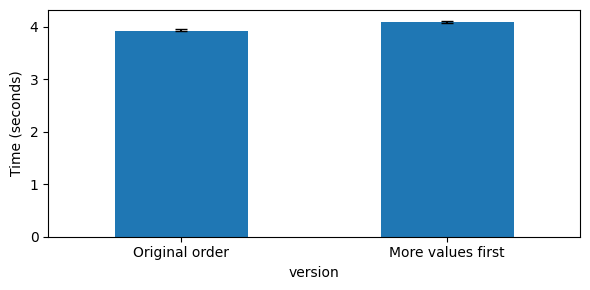

,median_s,shortest_s,longest_s,groups_checked
version,,,,
memory_fixed,3.924,3.919,3.948,28242.0
memory_reordered,4.087,4.074,4.113,14115.0


In [23]:
comparison = optimization_runs.groupby("version").agg(
    median_s=("seconds", "median"), shortest_s=("seconds", "min"),
    longest_s=("seconds", "max"), groups_checked=("partitions", "first"))
comparison = comparison.reindex(["memory_fixed", "memory_reordered"])
error = [comparison.median_s - comparison.shortest_s,
         comparison.longest_s - comparison.median_s]
comparison["median_s"].plot.bar(yerr=error, capsize=4, rot=0, figsize=(6, 3))
plt.xticks([0, 1], ["Original order", "More values first"])
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.savefig("results/optimization.png", dpi=150)
plt.show()
comparison.round(3)

Reordering halves groups checked (**28,242 → 14,115**), while median time changes **3.924 → 4.087 s**. Every reordered run was slower in this experiment, despite checking fewer groups.

## 6. AOI or BUC?

AOI is useful for summarising a class in a few readable groups. Here, it shows which age, education, occupation and worker groups are common among high-income records. The result is easy to explain, but some detail is lost during generalisation.

BUC is useful when exact counts are needed for many combinations of attributes. It keeps more detail than AOI, but produces many overlapping results and becomes slower as dimensions are added. The disk version can handle limited memory by using temporary files.

For this data, AOI is better for describing high-income groups. BUC is better for questions such as how many records match a particular combination of education, sex and worker class.

In [24]:
# Keep all timing measurements in one CSV; summaries stay in the notebook.
if rerun_timings:
    all_runs = pd.concat([
        support_runs.assign(experiment="minsup", version="disk"),
        memory_runs.assign(experiment="memory", version="disk"),
        dimension_runs.assign(experiment="dimensions", version="disk"),
        optimization_runs.assign(experiment="optimization"),
    ], ignore_index=True)
    all_runs = all_runs[[
        "experiment", "version", "repeat", "dimensions", "minsup", "memory_mb",
        "seconds", "cells", "spills", "partitions",
    ]]
    assert len(all_runs) == 39
    all_runs.to_csv("results/benchmark_runs.csv", index=False)

temporary.cleanup()